# Preparation des données

###1-1J'importe les  bibliothèques nécessaire

In [ ]:
# Importation des bibliothèques nécessaires
import pandas as pd  # Pour manipuler les données (comme Excel mais en plus puissant)
import numpy as np   # Pour les calculs mathématiques
import matplotlib.pyplot as plt  # Pour créer des graphiques
import seaborn as sns  # Pour créer de beaux graphiques
from datetime import datetime  # Pour manipuler les dates

# Pour les statistiques et le machine learning
from scipy import stats  # Pour les tests statistiques (ANOVA)
from sklearn.preprocessing import StandardScaler  # Pour standardiser les données
from sklearn.cluster import KMeans  # Pour le clustering (regroupement de clients)
from sklearn.linear_model import LinearRegression  # Pour la régression linéaire

# Configuration pour de beaux graphiques
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print(" Toutes les bibliothèques sont importées !")

 Toutes les bibliothèques sont importées !


In [ ]:
df = pd.read_excel('Online Retail.xlsx')
print("Dataset chargé avec succès dans un DataFrame nommé 'df'.")

Dataset chargé avec succès dans un DataFrame nommé 'df'.


In [ ]:
# Afficher les 5 premières lignes
print(" Aperçu des données :")
print(df.head())

print("\n Informations sur les colonnes :")
print(df.info())

print("\n Statistiques descriptives :")
print(df.describe())

 Aperçu des données :
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  

 Informations sur les colonnes :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-N

###1-2 Identifier les valeurs manquantes

In [ ]:
# Compter les valeurs manquantes par colonne
print(" Valeurs manquantes par colonne :")
print(df.isnull().sum())

# Visualiser en pourcentage
print("\n Pourcentage de valeurs manquantes :")
pourcentage_manquant = (df.isnull().sum() / len(df)) * 100
print(pourcentage_manquant[pourcentage_manquant > 0])

 Valeurs manquantes par colonne :
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

 Pourcentage de valeurs manquantes :
Description     0.268311
CustomerID     24.926694
dtype: float64


### 1-3 Supprimer les valeurs manquantes critiques

In [ ]:
# Avant nettoyage
print(f"Nombre de lignes AVANT nettoyage : {len(df)}")

# Supprimer les lignes où CustomerID est manquant
# (On ne peut pas analyser les clients sans identifiant)
df = df.dropna(subset=['CustomerID'])

# Supprimer les lignes où Description est manquante
df = df.dropna(subset=['Description'])

# Après nettoyage
print(f"Nombre de lignes APRÈS nettoyage : {len(df)}")
print(f" Lignes supprimées : {len(df) - len(df)}")

Nombre de lignes AVANT nettoyage : 541909
Nombre de lignes APRÈS nettoyage : 406829
 Lignes supprimées : 0


### 1-4 Supprimer les doublons

In [ ]:
# Vérifier les doublons
print(f" Nombre de lignes dupliquées : {df.duplicated().sum()}")

# Supprimer les doublons exacts
df = df.drop_duplicates()

print(f" Doublons supprimés. Nouvelles lignes : {len(df)}")

 Nombre de lignes dupliquées : 5225
 Doublons supprimés. Nouvelles lignes : 401604


###1-5 Supprimer les transactions annulés

In [ ]:
# Vérifier combien de factures commencent par 'C'
nb_annulations = df[df['InvoiceNo'].astype(str).str.startswith('C')].shape[0]
print(f" Nombre de lignes avec InvoiceNo commençant par 'C' : {nb_annulations}")

# Supprimer ces lignes
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

print(f" Annulations supprimées. Lignes restantes : {len(df)}")

 Nombre de lignes avec InvoiceNo commençant par 'C' : 8872
 Annulations supprimées. Lignes restantes : 392732


In [ ]:
# Afficher les types actuels
print(" Types de données actuels :")
print(df.dtypes)

# Convertir CustomerID en entier
df['CustomerID'] = df['CustomerID'].astype(int)

# Convertir InvoiceDate en format date
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='%d/%m/%Y %H:%M')

print("\n Types de données corrigés !")
print(df.dtypes)

 Types de données actuels :
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

 Types de données corrigés !
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID              int64
Country                object
dtype: object


In [ ]:
# Vérifier les quantités négatives ou nulles
print(f" Quantités négatives : {(df['Quantity'] < 0).sum()}")
print(f" Quantités nulles : {(df['Quantity'] == 0).sum()}")

# Supprimer ces lignes (on ne peut pas vendre 0 ou -5 produits normalement)
df = df[df['Quantity'] > 0]

# Même chose pour les prix
print(f" Prix négatifs ou nuls : {(df['UnitPrice'] <= 0).sum()}")
df = df[df['UnitPrice'] > 0]

print(f" Valeurs aberrantes supprimées. Lignes restantes : {len(df)}")

 Quantités négatives : 0
 Quantités nulles : 0
 Prix négatifs ou nuls : 40
 Valeurs aberrantes supprimées. Lignes restantes : 392692


In [ ]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Quantity,392692.0,13.119702,1.0,2.0,6.0,12.0,80995.0,180.492832
InvoiceDate,392692,2011-07-10 19:13:07.771892480,2010-12-01 08:26:00,2011-04-07 11:12:00,2011-07-31 12:02:00,2011-10-20 12:53:00,2011-12-09 12:50:00,NaN
UnitPrice,392692.0,3.125914,0.001,1.25,1.95,3.75,8142.75,22.241836
CustomerID,392692.0,15287.843865,12346.0,13955.0,15150.0,16791.0,18287.0,1713.539549


In [ ]:
# Compte le nombre d'identifiants uniques dans la colonne CustomerID
nb_clients = df['CustomerID'].nunique()
print(f"Nombre total de clients : {nb_clients}")

Nombre total de clients : 4372


###1-6 Créer une colonne TotalPrice

In [ ]:
# Créer la colonne TotalPrice = Quantity × UnitPrice
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

print(" Colonne TotalPrice créée !")
print("\n Aperçu des nouvelles données :")
print(df[['Quantity', 'UnitPrice', 'TotalPrice']].head(10))

 Colonne TotalPrice créée !

 Aperçu des nouvelles données :
   Quantity  UnitPrice  TotalPrice
0         6       2.55       15.30
1         6       3.39       20.34
2         8       2.75       22.00
3         6       3.39       20.34
4         6       3.39       20.34
5         2       7.65       15.30
6         6       4.25       25.50
7         6       1.85       11.10
8         6       1.85       11.10
9        32       1.69       54.08


#2-Analyse exploratoire

### 2-1 STATISTIQUES CLÉS

In [ ]:
print("=" * 70)
print("STATISTIQUES GÉNÉRALES DU E-COMMERCE")
print("=" * 70)

# 1. Nombre total de commandes (factures uniques)
nb_commandes = df['InvoiceNo'].nunique()
print(f" Nombre total de commandes : {nb_commandes:,}")

# 2. Nombre total de clients uniques
nb_clients = df['CustomerID'].nunique()
print(f" Nombre total de clients : {nb_clients:,}")

# 3. Nombre total de produits uniques
nb_produits = df['StockCode'].nunique()
print(f"  Nombre total de produits : {nb_produits:,}")

# 4. Nombre total de pays
nb_pays = df['Country'].nunique()
print(f" Nombre de pays : {nb_pays}")

# 5. Chiffre d'affaires total
ca_total = df['TotalPrice'].sum()
print(f" Chiffre d'affaires total : £{ca_total:,.2f}")

# 6. Panier moyen (CA total / nombre de commandes)
panier_moyen = ca_total / nb_commandes
print(f" Panier moyen : £{panier_moyen:.2f}")

# 7. Période couverte
date_debut = df['InvoiceDate'].min()
date_fin = df['InvoiceDate'].max()
print(f" Période : {date_debut.strftime('%d/%m/%Y')} → {date_fin.strftime('%d/%m/%Y')}")

print("=" * 70)

STATISTIQUES GÉNÉRALES DU E-COMMERCE
 Nombre total de commandes : 18,532
 Nombre total de clients : 4,338
  Nombre total de produits : 3,665
 Nombre de pays : 37
 Chiffre d'affaires total : £8,887,208.89
 Panier moyen : £479.56
 Période : 01/12/2010 → 09/12/2011


 ### 2.2 - CHIFFRE D'AFFAIRES PAR PAYS

In [ ]:
# Calculer le CA par pays
ca_par_pays = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False)

print("\n CHIFFRE D'AFFAIRES PAR PAYS (Top 15)")
print("=" * 50)
for i, (pays, ca) in enumerate(ca_par_pays.head(15).items(), 1):
    print(f"{i:2}. {pays:30} £{ca:>12,.2f}")


 CHIFFRE D'AFFAIRES PAR PAYS (Top 15)
 1. United Kingdom                 £7,285,024.64
 2. Netherlands                    £  285,446.34
 3. EIRE                           £  265,262.46
 4. Germany                        £  228,678.40
 5. France                         £  208,934.31
 6. Australia                      £  138,453.81
 7. Spain                          £   61,558.56
 8. Switzerland                    £   56,443.95
 9. Belgium                        £   41,196.34
10. Sweden                         £   38,367.83
11. Japan                          £   37,416.37
12. Norway                         £   36,165.44
13. Portugal                       £   33,375.84
14. Finland                        £   22,546.08
15. Singapore                      £   21,279.29


### 2.3 - TOP 10 DES PRODUITS LES PLUS VENDUS

In [ ]:
# TOP 10 par quantité vendue
top_produits_quantite = df.groupby(['StockCode', 'Description'])['Quantity'].sum().sort_values(ascending=False).head(10)

print("\n TOP 10 PRODUITS LES PLUS VENDUS (par quantité)")
print("=" * 80)
for i, ((code, desc), qty) in enumerate(top_produits_quantite.items(), 1):
    print(f"{i:2}. {desc[:50]:50} | Qté: {qty:>8,}")

# TOP 10 par chiffre d'affaires
top_produits_ca = df.groupby(['StockCode', 'Description'])['TotalPrice'].sum().sort_values(ascending=False).head(10)

print("\n TOP 10 PRODUITS LES PLUS RENTABLES (par CA)")
print("=" * 80)
for i, ((code, desc), ca) in enumerate(top_produits_ca.items(), 1):
    print(f"{i:2}. {desc[:50]:50} | CA: £{ca:>10,.2f}")


 TOP 10 PRODUITS LES PLUS VENDUS (par quantité)
 1. PAPER CRAFT , LITTLE BIRDIE                        | Qté:   80,995
 2. MEDIUM CERAMIC TOP STORAGE JAR                     | Qté:   77,916
 3. WORLD WAR 2 GLIDERS ASSTD DESIGNS                  | Qté:   54,319
 4. JUMBO BAG RED RETROSPOT                            | Qté:   46,078
 5. WHITE HANGING HEART T-LIGHT HOLDER                 | Qté:   36,706
 6. ASSORTED COLOUR BIRD ORNAMENT                      | Qté:   35,263
 7. PACK OF 72 RETROSPOT CAKE CASES                    | Qté:   33,670
 8. POPCORN HOLDER                                     | Qté:   30,919
 9. RABBIT NIGHT LIGHT                                 | Qté:   27,153
10. MINI PAINT SET VINTAGE                             | Qté:   26,076

 TOP 10 PRODUITS LES PLUS RENTABLES (par CA)
 1. PAPER CRAFT , LITTLE BIRDIE                        | CA: £168,469.60
 2. REGENCY CAKESTAND 3 TIER                           | CA: £142,264.75
 3. WHITE HANGING HEART T-LIGHT HOLDER           

### 2.4 - ANALYSE DE LA SAISONNALITÉ

####2.4.1 Analyse Mois

In [ ]:
# Créer une colonne 'Month' à partir de 'InvoiceDate'
df['Month'] = df['InvoiceDate'].dt.month

# Définir une liste de noms de mois pour l'affichage
mois = [
    "Janvier", "Février", "Mars", "Avril", "Mai", "Juin",
    "Juillet", "Août", "Septembre", "Octobre", "Novembre", "Décembre"
]

# Ventes par mois
ventes_par_mois = df.groupby('Month')['TotalPrice'].sum()

print("\n VENTES PAR MOIS")
print("=" * 40)
for mois_num, ca in ventes_par_mois.items():
    # Assurez-vous que mois_num est dans les limites de la liste `mois`
    if 1 <= mois_num <= 12:
        mois_nom = mois[mois_num - 1]
        print(f"{mois_nom:10} : £{ca:>12,.2f}")
    else:
        print(f"Mois invalide ({mois_num}) : £{ca:>12,.2f}")


 VENTES PAR MOIS
Janvier    : £  568,101.31
Février    : £  446,084.92
Mars       : £  594,081.76
Avril      : £  468,374.33
Mai        : £  677,355.15
Juin       : £  660,046.05
Juillet    : £  598,962.90
Août       : £  644,051.04
Septembre  : £  950,690.20
Octobre    : £1,035,642.45
Novembre   : £1,156,205.61
Décembre   : £1,087,613.17


####2.4.1 Analyse Semaines

In [ ]:
# Créer une colonne 'DayOfWeek' à partir de 'InvoiceDate' (Lundi=0, Dimanche=6)
df['DayOfWeek'] = df['InvoiceDate'].dt.dayofweek

# Définir une liste de noms de jours pour l'affichage
jours = [
    "Lundi", "Mardi", "Mercredi", "Jeudi", "Vendredi", "Samedi", "Dimanche"
]

# Ventes par jour de la semaine
ventes_par_jour = df.groupby('DayOfWeek')['TotalPrice'].sum()

print("\n VENTES PAR JOUR DE LA SEMAINE")
print("=" * 40)
for jour_num, ca in ventes_par_jour.items():
    # Assurez-vous que jour_num est dans les limites de la liste `jours`
    if 0 <= jour_num <= 6:
        jour_nom = jours[jour_num]
        print(f"{jour_nom:10} : £{ca:>12,.2f}")
    else:
        print(f"Jour invalide ({jour_num}) : £{ca:>12,.2f}")


 VENTES PAR JOUR DE LA SEMAINE
Lundi      : £1,363,604.40
Mardi      : £1,697,733.80
Mercredi   : £1,584,283.83
Jeudi      : £1,973,015.73
Vendredi   : £1,483,080.81
Dimanche   : £  785,490.32


### 2.4 - ANALYSE DE LA SAISONNALITÉ

In [ ]:
# Configuration pour de beaux graphiques
import warnings
warnings.filterwarnings('ignore')

# Style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

### 3.1 Visualition 1 : Chiffre d'affaires par pays (Top 10)

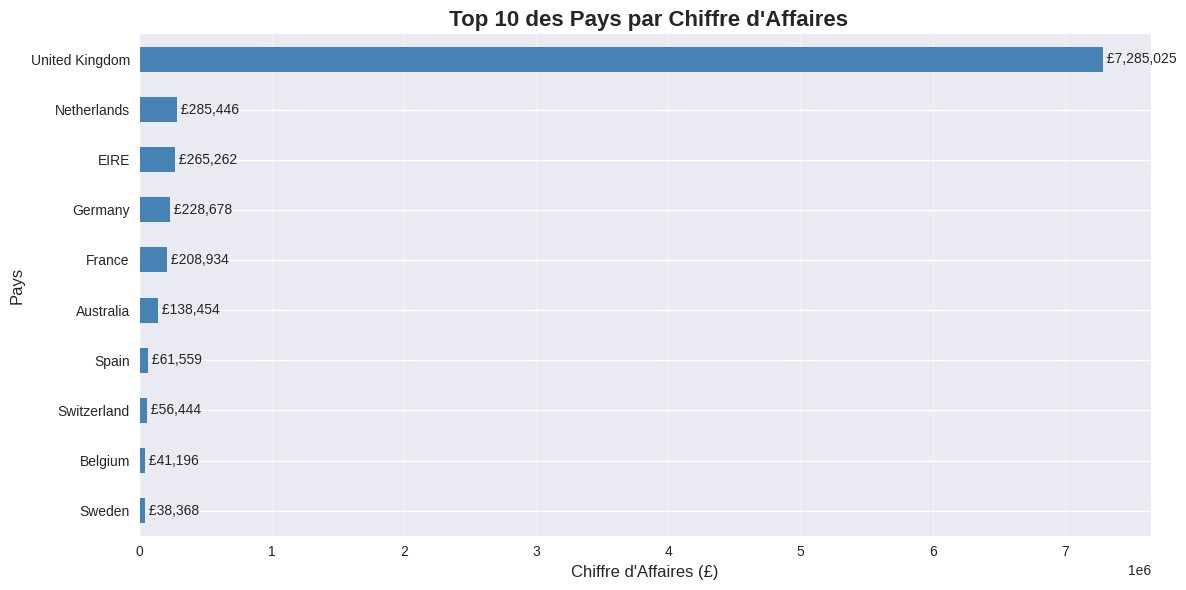

In [ ]:
# Top 10 pays par CA
top10_pays = ca_par_pays.head(10)

plt.figure(figsize=(12, 6))
top10_pays.plot(kind='barh', color='steelblue')
plt.title(' Top 10 des Pays par Chiffre d\'Affaires', fontsize=16, fontweight='bold')
plt.xlabel('Chiffre d\'Affaires (£)', fontsize=12)
plt.ylabel('Pays', fontsize=12)
plt.gca().invert_yaxis()  # Inverser pour avoir le plus grand en haut
plt.grid(axis='x', alpha=0.3)

# Ajouter les valeurs sur les barres
for i, v in enumerate(top10_pays):
    plt.text(v, i, f' £{v:,.0f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

### 3.2 Visualition 2 : Évolution des ventes par mois

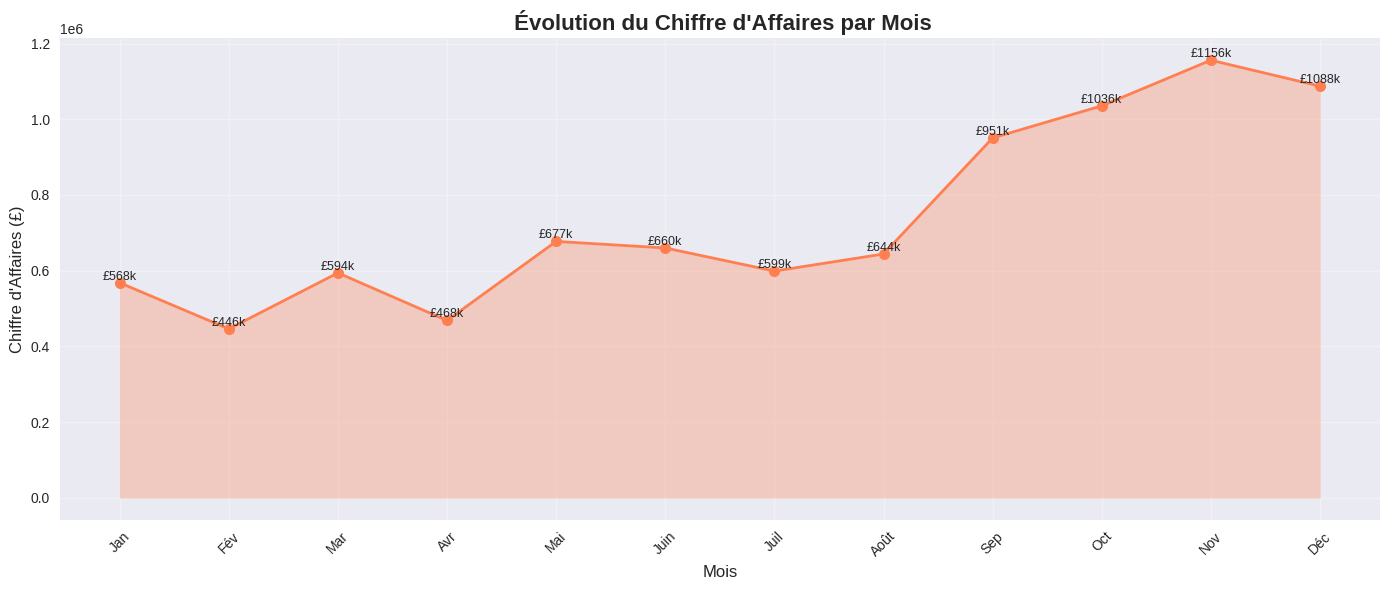

In [ ]:
# Ordre correct des mois (abréviations françaises)
ordre_mois = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Juin',
              'Juil', 'Août', 'Sep', 'Oct', 'Nov', 'Déc']

# Créer une colonne 'MonthName' à partir de 'Month' en utilisant les abréviations
month_to_abr = {
    1: 'Jan', 2: 'Fév', 3: 'Mar', 4: 'Avr', 5: 'Mai', 6: 'Juin',
    7: 'Juil', 8: 'Août', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Déc'
}
df['MonthName'] = df['Month'].map(month_to_abr)

# Créer un DataFrame pour l'ordre
ventes_mois_df = df.groupby('MonthName')['TotalPrice'].sum().reindex(ordre_mois)

plt.figure(figsize=(14, 6))
plt.plot(ventes_mois_df.index, ventes_mois_df.values, marker='o',
         linewidth=2, markersize=8, color='coral')
plt.fill_between(range(len(ventes_mois_df)), ventes_mois_df.values, alpha=0.3, color='coral')

plt.title(' Évolution du Chiffre d\'Affaires par Mois', fontsize=16, fontweight='bold')
plt.xlabel('Mois', fontsize=12)
plt.ylabel('Chiffre d\'Affaires (£)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

# Ajouter les valeurs
for i, v in enumerate(ventes_mois_df.values):
    plt.text(i, v, f'£{v/1000:.0f}k', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### 3.3 Visualition 3 : Ventes par jour de la semaine

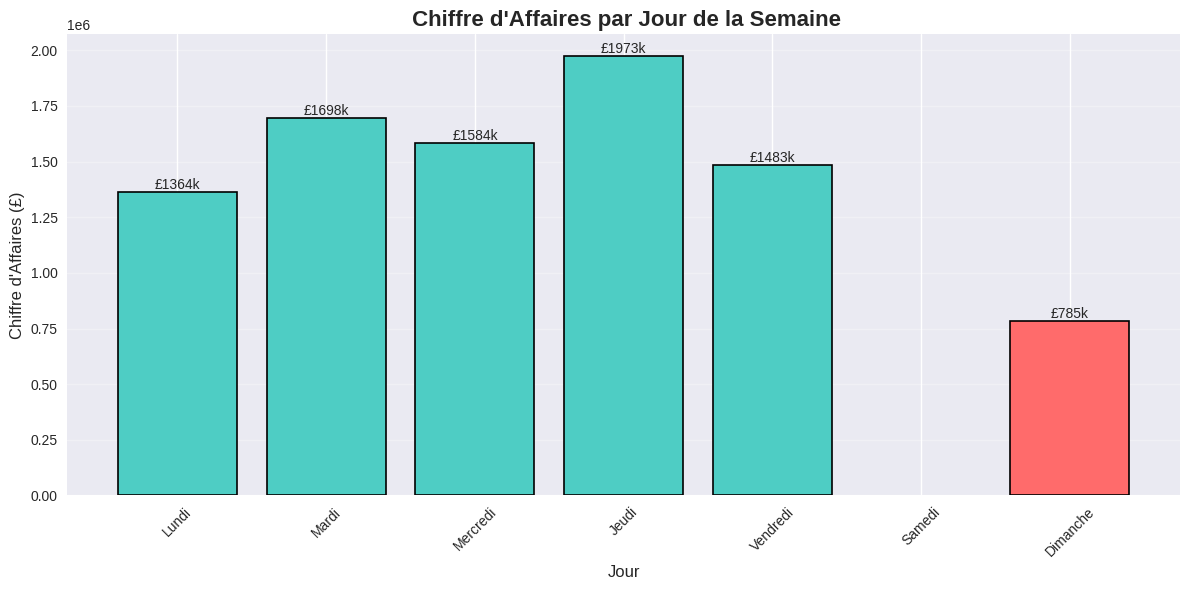

In [ ]:
# Ventes par jour avec l'ordre correct
ordre_jours = ['Lundi', 'Mardi', 'Mercredi', 'Jeudi', 'Vendredi', 'Samedi', 'Dimanche']

# Créer une colonne 'DayName' à partir de 'DayOfWeek'
day_to_name = {
    0: 'Lundi', 1: 'Mardi', 2: 'Mercredi', 3: 'Jeudi',
    4: 'Vendredi', 5: 'Samedi', 6: 'Dimanche'
}
df['DayName'] = df['DayOfWeek'].map(day_to_name)

ventes_jour_df = df.groupby('DayName')['TotalPrice'].sum().reindex(ordre_jours)

plt.figure(figsize=(12, 6))
colors = ['#FF6B6B' if jour in ['Samedi', 'Dimanche'] else '#4ECDC4' for jour in ordre_jours]
plt.bar(ventes_jour_df.index, ventes_jour_df.values, color=colors, edgecolor='black', linewidth=1.2)

plt.title(' Chiffre d\'Affaires par Jour de la Semaine', fontsize=16, fontweight='bold')
plt.xlabel('Jour', fontsize=12)
plt.ylabel('Chiffre d\'Affaires (£)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

# Ajouter les valeurs
for i, v in enumerate(ventes_jour_df.values):
    plt.text(i, v, f'£{v/1000:.0f}k', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

### 3.4 Visualition 4 : Distribution des montants de commande

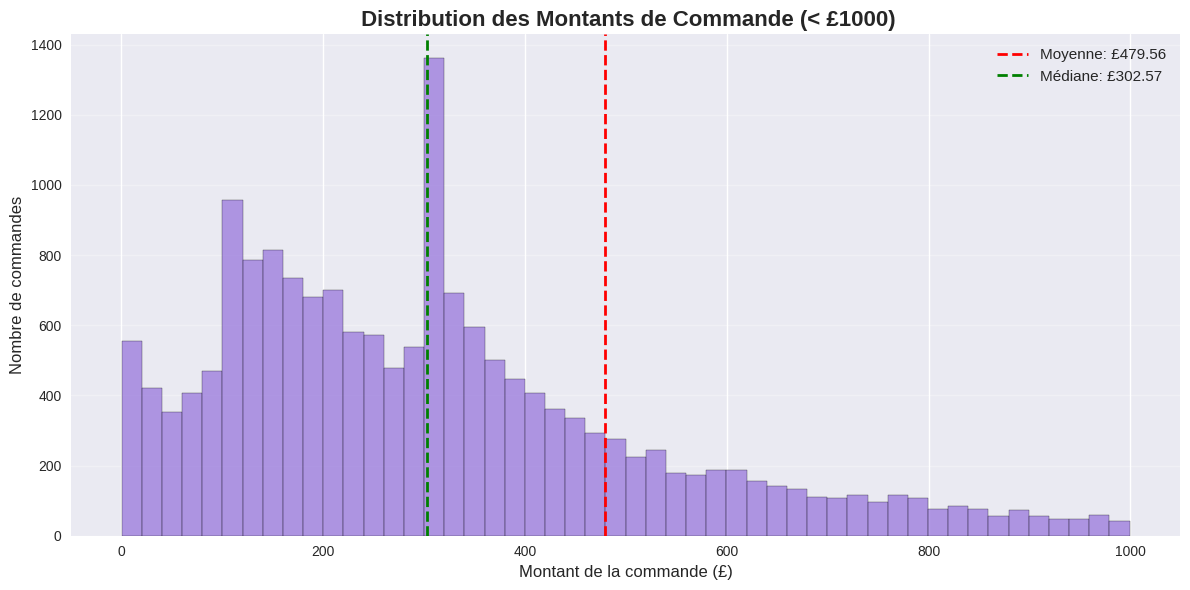

In [ ]:
# Distribution des montants par commande
commandes = df.groupby('InvoiceNo')['TotalPrice'].sum()

plt.figure(figsize=(12, 6))
plt.hist(commandes[commandes < 1000], bins=50, color='mediumpurple', edgecolor='black', alpha=0.7)
plt.title(' Distribution des Montants de Commande (< £1000)', fontsize=16, fontweight='bold')
plt.xlabel('Montant de la commande (£)', fontsize=12)
plt.ylabel('Nombre de commandes', fontsize=12)
plt.axvline(commandes.mean(), color='red', linestyle='--', linewidth=2, label=f'Moyenne: £{commandes.mean():.2f}')
plt.axvline(commandes.median(), color='green', linestyle='--', linewidth=2, label=f'Médiane: £{commandes.median():.2f}')
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 3.5 Visualition 5 : Heatmap - Ventes par Mois × Jour de la semaine

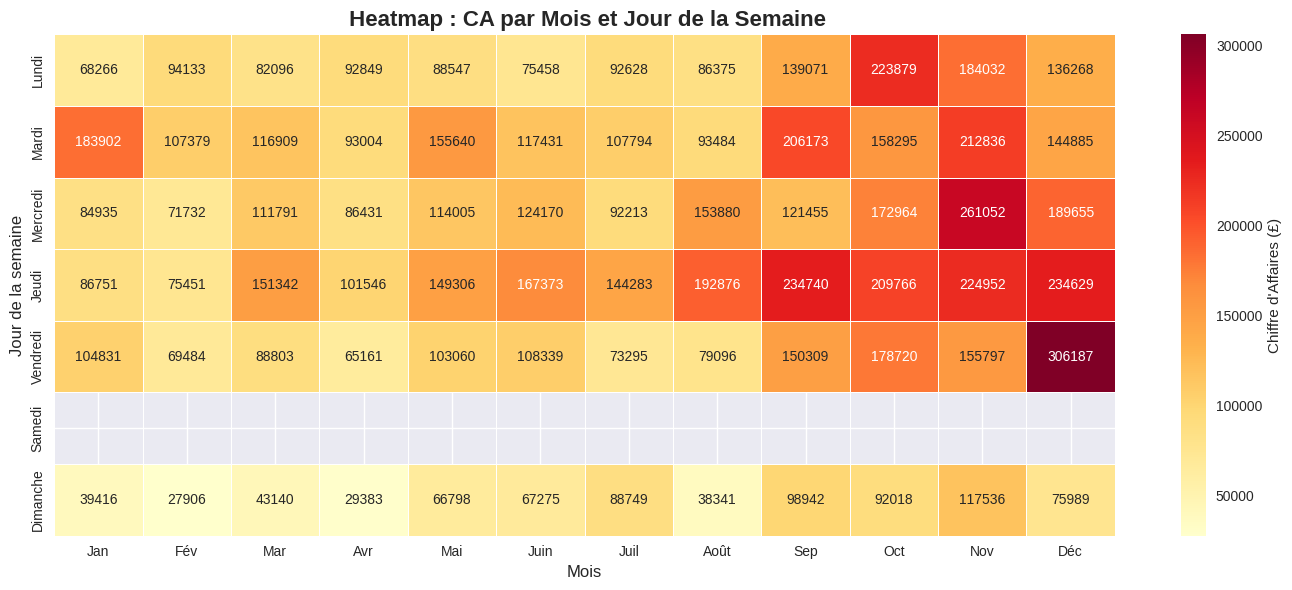

In [ ]:
# Créer une table croisée
heatmap_data = df.pivot_table(
    values='TotalPrice',
    index='DayName',
    columns='MonthName',
    aggfunc='sum'
)

# Réordonner
heatmap_data = heatmap_data.reindex(ordre_jours)
heatmap_data = heatmap_data[ordre_mois]

plt.figure(figsize=(14, 6))
sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlOrRd',
            cbar_kws={'label': 'Chiffre d\'Affaires (£)'}, linewidths=0.5)
plt.title(' Heatmap : CA par Mois et Jour de la Semaine', fontsize=16, fontweight='bold')
plt.xlabel('Mois', fontsize=12)
plt.ylabel('Jour de la semaine', fontsize=12)
plt.tight_layout()
plt.show()

3.6 Visualition 6 :  Top 10 produits

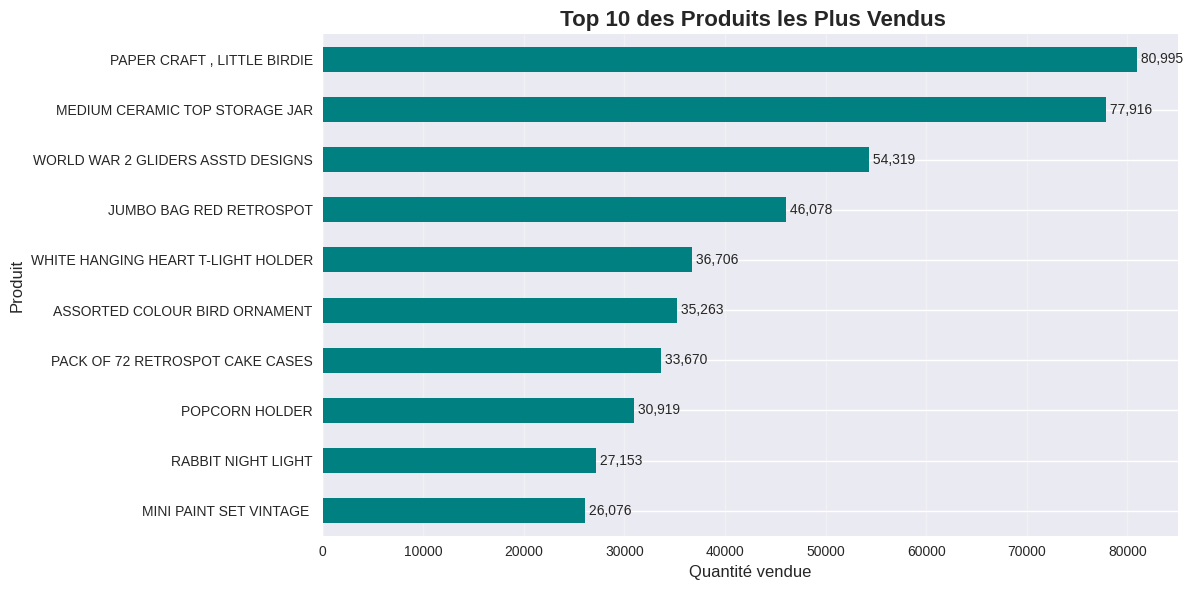

In [ ]:
# Top 10 produits par quantité
top10_produits = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
top10_produits.plot(kind='barh', color='teal')
plt.title(' Top 10 des Produits les Plus Vendus', fontsize=16, fontweight='bold')
plt.xlabel('Quantité vendue', fontsize=12)
plt.ylabel('Produit', fontsize=12)
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)

# Ajouter les valeurs
for i, v in enumerate(top10_produits):
    plt.text(v, i, f' {v:,.0f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

3.7 Visualition 7 :  Nombre de commandes par mois

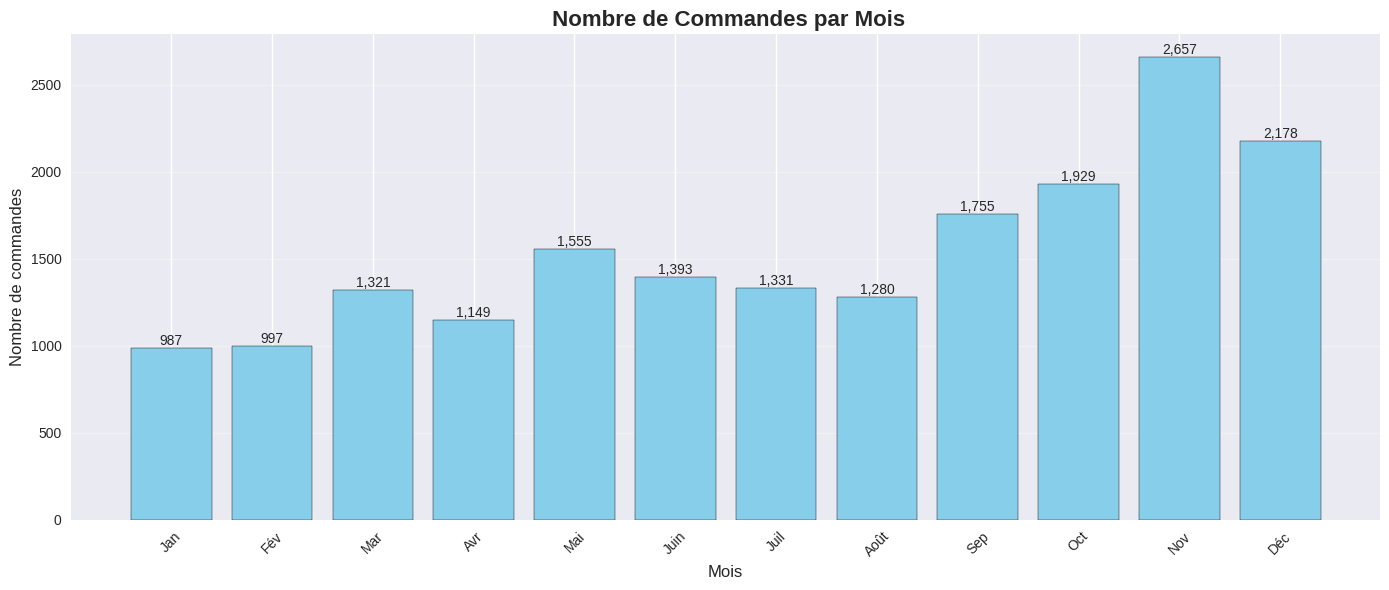

In [ ]:
# Nombre de commandes par mois
nb_commandes_mois = df.groupby('MonthName')['InvoiceNo'].nunique().reindex(ordre_mois)

plt.figure(figsize=(14, 6))
plt.bar(nb_commandes_mois.index, nb_commandes_mois.values, color='skyblue', edgecolor='black')
plt.title(' Nombre de Commandes par Mois', fontsize=16, fontweight='bold')
plt.xlabel('Mois', fontsize=12)
plt.ylabel('Nombre de commandes', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

for i, v in enumerate(nb_commandes_mois.values):
    plt.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# 4: Statistiques descriptives

4.1 Caluls statistiques de base

In [ ]:
print("=" * 70)
print(" STATISTIQUES DESCRIPTIVES DES VARIABLES NUMÉRIQUES")
print("=" * 70)

# Sélectionner les colonnes numériques importantes
colonnes_numeriques = ['Quantity', 'UnitPrice', 'TotalPrice']

# Statistiques détaillées
stats_desc = df[colonnes_numeriques].describe()
print(stats_desc)

print("\n" + "=" * 70)
print(" STATISTIQUES COMPLÉMENTAIRES")
print("=" * 70)

# Calculs manuels pour bien comprendre
for col in colonnes_numeriques:
    print(f"\n🔹 {col}")
    print(f"   Moyenne (mean)      : {df[col].mean():.2f}")
    print(f"   Médiane (median)    : {df[col].median():.2f}")
    print(f"   Écart-type (std)    : {df[col].std():.2f}")
    print(f"   Variance            : {df[col].var():.2f}")
    print(f"   Minimum             : {df[col].min():.2f}")
    print(f"   Maximum             : {df[col].max():.2f}")
    print(f"   Q1 (25%)            : {df[col].quantile(0.25):.2f}")
    print(f"   Q3 (75%)            : {df[col].quantile(0.75):.2f}")

 STATISTIQUES DESCRIPTIVES DES VARIABLES NUMÉRIQUES
            Quantity      UnitPrice     TotalPrice
count  392692.000000  392692.000000  392692.000000
mean       13.119702       3.125914      22.631500
std       180.492832      22.241836     311.099224
min         1.000000       0.001000       0.001000
25%         2.000000       1.250000       4.950000
50%         6.000000       1.950000      12.450000
75%        12.000000       3.750000      19.800000
max     80995.000000    8142.750000  168469.600000

 STATISTIQUES COMPLÉMENTAIRES

🔹 Quantity
   Moyenne (mean)      : 13.12
   Médiane (median)    : 6.00
   Écart-type (std)    : 180.49
   Variance            : 32577.66
   Minimum             : 1.00
   Maximum             : 80995.00
   Q1 (25%)            : 2.00
   Q3 (75%)            : 12.00

🔹 UnitPrice
   Moyenne (mean)      : 3.13
   Médiane (median)    : 1.95
   Écart-type (std)    : 22.24
   Variance            : 494.70
   Minimum             : 0.00
   Maximum             : 814

4.2 ANALYSE DES CORRÉLATIONS:

In [ ]:
print("\n" + "=" * 70)
print(" MATRICE DE CORRÉLATION")
print("=" * 70)

# Calculer la matrice de corrélation
correlation_matrix = df[colonnes_numeriques].corr()
print(correlation_matrix)

# Interprétation textuelle
print("\n Interprétation des corrélations :")
print("-" * 70)

# Corrélation Quantity vs UnitPrice
corr_qty_price = correlation_matrix.loc['Quantity', 'UnitPrice']
print(f"Quantity ↔ UnitPrice : {corr_qty_price:.3f}")
if abs(corr_qty_price) < 0.3:
    print("   → Corrélation FAIBLE : pas de relation claire")
elif abs(corr_qty_price) < 0.7:
    print("   → Corrélation MODÉRÉE")
else:
    print("   → Corrélation FORTE")

# Corrélation Quantity vs TotalPrice
corr_qty_total = correlation_matrix.loc['Quantity', 'TotalPrice']
print(f"\nQuantity ↔ TotalPrice : {corr_qty_total:.3f}")
if corr_qty_total > 0.7:
    print("   → Corrélation FORTE POSITIVE : plus on achète, plus le total est élevé (logique !)")

# Corrélation UnitPrice vs TotalPrice
corr_price_total = correlation_matrix.loc['UnitPrice', 'TotalPrice']
print(f"\nUnitPrice ↔ TotalPrice : {corr_price_total:.3f}")
if corr_price_total > 0.5:
    print("   → Corrélation POSITIVE : les produits chers augmentent le total")


 MATRICE DE CORRÉLATION
            Quantity  UnitPrice  TotalPrice
Quantity    1.000000  -0.004578    0.914451
UnitPrice  -0.004578   1.000000    0.081619
TotalPrice  0.914451   0.081619    1.000000

 Interprétation des corrélations :
----------------------------------------------------------------------
Quantity ↔ UnitPrice : -0.005
   → Corrélation FAIBLE : pas de relation claire

Quantity ↔ TotalPrice : 0.914
   → Corrélation FORTE POSITIVE : plus on achète, plus le total est élevé (logique !)

UnitPrice ↔ TotalPrice : 0.082


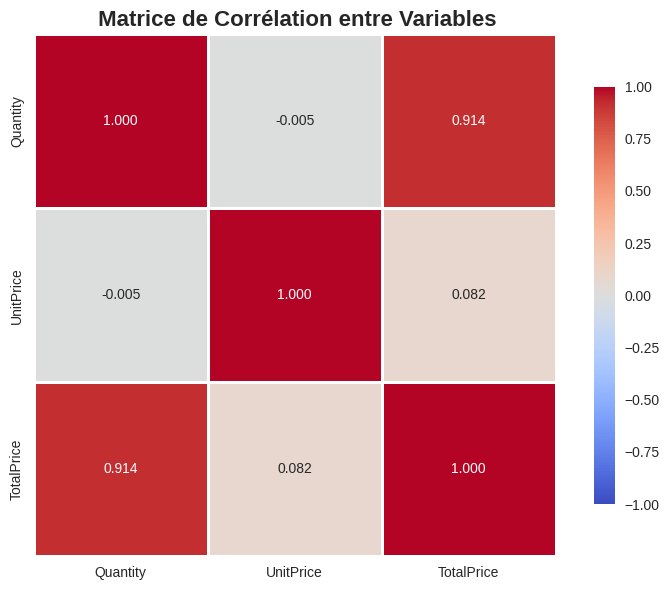

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=2, cbar_kws={"shrink": 0.8},
            fmt='.3f', vmin=-1, vmax=1)
plt.title(' Matrice de Corrélation entre Variables', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
df = pd.read_excel('Online Retail.xlsx')
print("Dataset chargé avec succès dans un DataFrame nommé 'df'.")

Dataset chargé avec succès dans un DataFrame nommé 'df'.


#Test Statistique  - ANOVA

5.1 - Hypothèses de l'ANOVA

In [ ]:
print("=" * 70)
print(" TEST ANOVA : MONTANT MOYEN DES COMMANDES PAR PAYS")
print("=" * 70)

print("\n HYPOTHÈSES :")
print("-" * 70)
print("H0 (hypothèse nulle)      : Toutes les moyennes sont égales")
print("                            → Le pays n'influence PAS le montant")
print("\nH1 (hypothèse alternative): Au moins une moyenne diffère")
print("                            → Le pays INFLUENCE le montant")
print("\n  Seuil de significativité : α = 0.05 (5%)")
print("   → Si p-value < 0.05 : on rejette H0 (différences significatives)")
print("   → Si p-value ≥ 0.05 : on accepte H0 (pas de différence)")

 TEST ANOVA : MONTANT MOYEN DES COMMANDES PAR PAYS

 HYPOTHÈSES :
----------------------------------------------------------------------
H0 (hypothèse nulle)      : Toutes les moyennes sont égales
                            → Le pays n'influence PAS le montant

H1 (hypothèse alternative): Au moins une moyenne diffère
                            → Le pays INFLUENCE le montant

  Seuil de significativité : α = 0.05 (5%)
   → Si p-value < 0.05 : on rejette H0 (différences significatives)
   → Si p-value ≥ 0.05 : on accepte H0 (pas de différence)


5.2 - Calculer les montants par commande et par pays

In [ ]:
# S'assurer que la colonne TotalPrice existe, car df a pu être rechargé
if 'TotalPrice' not in df.columns:
    df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# Agréger par commande (InvoiceNo) pour avoir le montant total de chaque commande
commandes_pays = df.groupby(['InvoiceNo', 'Country'])['TotalPrice'].sum().reset_index()

print("\n Aperçu des données pour l'ANOVA :")
print(commandes_pays.head(10))

# Statistiques descriptives par pays
print("\n MONTANT MOYEN DES COMMANDES PAR PAYS (Top 10)")
print("-" * 70)
moyennes_pays = commandes_pays.groupby('Country')['TotalPrice'].agg(['mean', 'median', 'count']).sort_values('mean', ascending=False)

for pays, row in moyennes_pays.head(10).iterrows():
    print(f"{pays:25} | Moyenne: £{row['mean']:8.2f} | Médiane: £{row['median']:8.2f} | N={int(row['count']):5}")


 Aperçu des données pour l'ANOVA :
  InvoiceNo         Country  TotalPrice
0    536365  United Kingdom      139.12
1    536366  United Kingdom       22.20
2    536367  United Kingdom      278.73
3    536368  United Kingdom       70.05
4    536369  United Kingdom       17.85
5    536370          France      855.86
6    536371  United Kingdom      204.00
7    536372  United Kingdom       22.20
8    536373  United Kingdom      259.86
9    536374  United Kingdom      350.40

 MONTANT MOYEN DES COMMANDES PAR PAYS (Top 10)
----------------------------------------------------------------------
Netherlands               | Moyenne: £ 2818.43 | Médiane: £  637.72 | N=  101
Australia                 | Moyenne: £ 1986.63 | Médiane: £  358.25 | N=   69
Lebanon                   | Moyenne: £ 1693.88 | Médiane: £ 1693.88 | N=    1
Japan                     | Moyenne: £ 1262.16 | Médiane: £  143.04 | N=   28
Brazil                    | Moyenne: £ 1143.60 | Médiane: £ 1143.60 | N=    1
RSA            

In [ ]:
from scipy.stats import f_oneway

print("\n EFFECTUER LE TEST ANOVA")
print("=" * 70)

# Filtrer les pays avec au moins 2 commandes pour l'ANOVA
counts_per_country = commandes_pays['Country'].value_counts()
pays_suffisants = counts_per_country[counts_per_country >= 2].index

commandes_filtrees = commandes_pays[commandes_pays['Country'].isin(pays_suffisants)]

# Préparer les groupes de données pour l'ANOVA
groups = []
for name, group in commandes_filtrees.groupby('Country'):
    groups.append(group['TotalPrice'])

# Exécuter le test ANOVA
if len(groups) > 1: # Assurez-vous qu'il y a au moins deux groupes pour l'ANOVA
    f_statistic, p_value = f_oneway(*groups)

    print(f" Statistiques F : {f_statistic:.2f}")
    print(f" Valeur p (p-value) : {p_value:.3e}") # Format scientifique pour petite valeur p

    print("\n Interprétation :")
    print("-" * 70)
    alpha = 0.05

    if p_value < alpha:
        print(f" → La p-value ({p_value:.3e}) est INFÉRIEURE à {alpha}.")
        print("   Nous rejetons l'hypothèse nulle (H0).")
        print("   Conclusion : Il existe une différence significative dans les montants moyens des commandes entre au moins deux pays.")
        print("   Cela confirme que le pays influence le montant moyen des commandes.")
    else:
        print(f" → La p-value ({p_value:.3e}) est SUPÉRIEURE ou ÉGALE à {alpha}.")
        print("   Nous ne rejetons PAS l'hypothèse nulle (H0).")
        print("   Conclusion : Il n'y a pas de preuve suffisante pour affirmer une différence significative entre les montants moyens des commandes des pays.")
else:
    print("Pas assez de groupes (pays avec au moins 2 commandes) pour effectuer le test ANOVA.")

print("=" * 70)



 EFFECTUER LE TEST ANOVA
 Statistiques F : 6.72
 Valeur p (p-value) : 1.638e-30

 Interprétation :
----------------------------------------------------------------------
 → La p-value (1.638e-30) est INFÉRIEURE à 0.05.
   Nous rejetons l'hypothèse nulle (H0).
   Conclusion : Il existe une différence significative dans les montants moyens des commandes entre au moins deux pays.
   Cela confirme que le pays influence le montant moyen des commandes.


5.3 - Réaliser l'ANOVA

In [ ]:
# Préparer les données : créer des groupes par pays
# On va prendre les top 5 pays pour simplifier (sinon trop de pays)
top_pays = commandes_pays['Country'].value_counts().head(5).index
commandes_top_pays = commandes_pays[commandes_pays['Country'].isin(top_pays)]

# Créer des listes de montants par pays
groupes = [commandes_top_pays[commandes_top_pays['Country'] == pays]['TotalPrice'].values
           for pays in top_pays]

# Réaliser l'ANOVA
f_statistic, p_value = stats.f_oneway(*groupes)

print("\n" + "=" * 70)
print(" RÉSULTATS DU TEST ANOVA")
print("=" * 70)
print(f"Statistique F : {f_statistic:.4f}")
print(f"P-value       : {p_value:.6f}")
print("-" * 70)

# Interprétation
print("\n INTERPRÉTATION :")
if p_value < 0.05:
    print(f" P-value ({p_value:.6f}) < 0.05")
    print("   → On REJETTE l'hypothèse nulle (H0)")
    print("   → Conclusion : Le montant moyen des commandes DIFFÈRE significativement selon les pays")
    print("   → Les pays ont un comportement d'achat différent !")
else:
    print(f" P-value ({p_value:.6f}) ≥ 0.05")
    print("   → On ACCEPTE l'hypothèse nulle (H0)")
    print("   → Conclusion : Pas de différence significative entre les pays")


 RÉSULTATS DU TEST ANOVA
Statistique F : 3.4235
P-value       : 0.008350
----------------------------------------------------------------------

 INTERPRÉTATION :
 P-value (0.008350) < 0.05
   → On REJETTE l'hypothèse nulle (H0)
   → Conclusion : Le montant moyen des commandes DIFFÈRE significativement selon les pays
   → Les pays ont un comportement d'achat différent !


Visualisation des distributions par pays

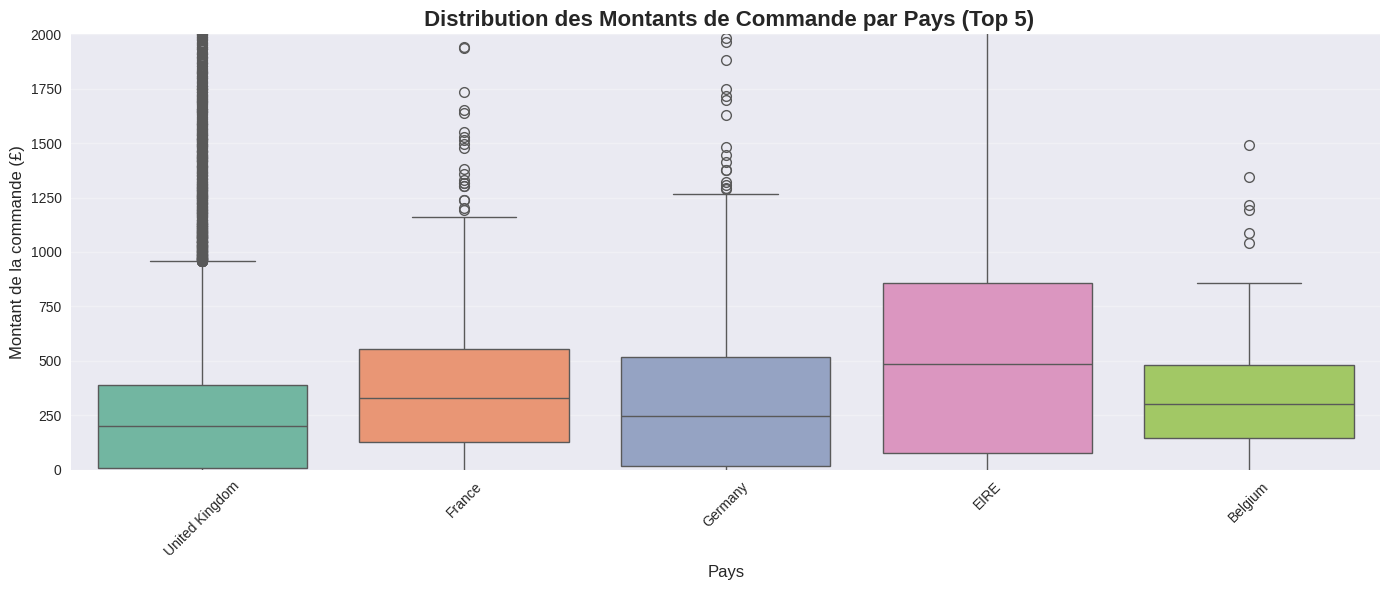


💡 Ce graphique montre la distribution des montants par pays.
   Les 'boîtes' représentent 50% des données (entre Q1 et Q3).
   Les points isolés = valeurs extrêmes (outliers).


In [ ]:
import seaborn as sns # Ajout de l'import de seaborn
import matplotlib.pyplot as plt # Assurer que plt est aussi importé pour plot_simultaneous

plt.figure(figsize=(14, 6))
sns.boxplot(data=commandes_top_pays, x='Country', y='TotalPrice', palette='Set2')
plt.title(' Distribution des Montants de Commande par Pays (Top 5)', fontsize=16, fontweight='bold')
plt.xlabel('Pays', fontsize=12)
plt.ylabel('Montant de la commande (£)', fontsize=12)
plt.xticks(rotation=45)
plt.ylim(0, 2000)  # Limiter pour mieux voir (ajuste selon tes données)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n💡 Ce graphique montre la distribution des montants par pays.")
print("   Les 'boîtes' représentent 50% des données (entre Q1 et Q3).")
print("   Les points isolés = valeurs extrêmes (outliers).")

 6.1 - Préparation des données pour la régression

In [ ]:
print("=" * 70)
print(" PRÉPARATION DES DONNÉES POUR LA RÉGRESSION")
print("=" * 70)

# Créer une copie pour la régression
df_regression = df.copy()

# Calculer le CA par pays (définition ajoutée ici pour éviter NameError)
ca_par_pays = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False)

# 1. Variables explicatives (X) et variable à prédire (y)
# On va prendre les variables demandées

# Encoder le jour de la semaine (déjà fait : DayOfWeek)
# Encoder les pays en variables fictives (one-hot encoding)
print("\n Encodage des pays en variables fictives...")

# On garde les top 10 pays pour simplifier
top10_pays_list = ca_par_pays.head(10).index.tolist()
df_regression_filtered = df_regression[df_regression['Country'].isin(top10_pays_list)]

# One-hot encoding des pays (drop_first=True pour éviter la multicolinéarité)
pays_dummies = pd.get_dummies(df_regression_filtered['Country'], prefix='Pays', drop_first=True)

print(f" {len(pays_dummies.columns)} variables créées pour les pays")
print(f"   Colonnes : {list(pays_dummies.columns[:5])}... (et {len(pays_dummies.columns)-5} autres)")


 PRÉPARATION DES DONNÉES POUR LA RÉGRESSION

 Encodage des pays en variables fictives...
 9 variables créées pour les pays
   Colonnes : ['Pays_Belgium', 'Pays_EIRE', 'Pays_France', 'Pays_Germany', 'Pays_Netherlands']... (et 4 autres)


6.2 - Construction du modèle

In [ ]:
# Créer le DataFrame final avec toutes les variables

# Recréer la colonne DayOfWeek si elle n'existe pas dans df_regression_filtered
# Utiliser .loc pour éviter le SettingWithCopyWarning
if 'DayOfWeek' not in df_regression_filtered.columns:
    df_regression_filtered.loc[:, 'DayOfWeek'] = df_regression_filtered['InvoiceDate'].dt.dayofweek

X = pd.concat([
    df_regression_filtered[['Quantity', 'UnitPrice', 'DayOfWeek']],
    pays_dummies
], axis=1)

y = df_regression_filtered['TotalPrice']

print(f"\n Dimensions des données :")
print(f"   X (variables explicatives) : {X.shape}")
print(f"   y (variable à prédire)     : {y.shape}")

# Vérifier qu'il n'y a pas de valeurs manquantes
print(f"\n Valeurs manquantes dans X : {X.isnull().sum().sum()}")
print(f" Valeurs manquantes dans y : {y.isnull().sum()}")


 Dimensions des données :
   X (variables explicatives) : (532422, 12)
   y (variable à prédire)     : (532422,)

 Valeurs manquantes dans X : 0
 Valeurs manquantes dans y : 0


 6.3 - Entraînement du modèle de régression

In [ ]:
from sklearn.linear_model import LinearRegression # Importation ajoutée
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Créer et entraîner le modèle
model = LinearRegression()
model.fit(X, y)

# Prédictions
y_pred = model.predict(X)

# Calculer le R² (coefficient de détermination)

r2 = r2_score(y, y_pred)
mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print("\n" + "=" * 70)
print(" RÉSULTATS DE LA RÉGRESSION LINÉAIRE MULTIPLE")
print("=" * 70)

print(f"\n PERFORMANCE DU MODÈLE :")
print(f"   R² (coefficient de détermination) : {r2:.4f}")
print(f"   → Le modèle explique {r2*100:.2f}% de la variance du TotalPrice")
print(f"\n   MAE (erreur absolue moyenne)      : £{mae:.2f}")
print(f"   RMSE (erreur quadratique moyenne)  : £{rmse:.2f}")


 RÉSULTATS DE LA RÉGRESSION LINÉAIRE MULTIPLE

 PERFORMANCE DU MODÈLE :
   R² (coefficient de détermination) : 0.8139
   → Le modèle explique 81.39% de la variance du TotalPrice

   MAE (erreur absolue moyenne)      : £16.23
   RMSE (erreur quadratique moyenne)  : £164.72


6.4 - Coefficients du modèle

In [ ]:
print("\n" + "=" * 70)
print(" COEFFICIENTS DU MODÈLE")
print("=" * 70)

# Intercept (ordonnée à l'origine)
print(f"\n🔹 Intercept (β0) : £{model.intercept_:.4f}")

# Coefficients des variables
coefficients = pd.DataFrame({
    'Variable': X.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False)

print("\n Top 10 variables avec le plus fort impact POSITIF :")
print(coefficients.head(10).to_string(index=False))

print("\n Top 10 variables avec le plus fort impact NÉGATIF :")
print(coefficients.tail(10).to_string(index=False))


 COEFFICIENTS DU MODÈLE

🔹 Intercept (β0) : £9.9225

 Top 10 variables avec le plus fort impact POSITIF :
           Variable  Coefficient
           Quantity     1.540110
          Pays_EIRE     0.488047
         Pays_Spain     0.067981
          DayOfWeek    -0.570618
          UnitPrice    -0.643272
   Pays_Switzerland    -1.350971
       Pays_Germany    -1.652449
        Pays_France    -2.110230
Pays_United Kingdom    -2.345177
       Pays_Belgium    -3.516527

 Top 10 variables avec le plus fort impact NÉGATIF :
           Variable  Coefficient
         Pays_Spain     0.067981
          DayOfWeek    -0.570618
          UnitPrice    -0.643272
   Pays_Switzerland    -1.350971
       Pays_Germany    -1.652449
        Pays_France    -2.110230
Pays_United Kingdom    -2.345177
       Pays_Belgium    -3.516527
   Pays_Netherlands   -16.895817
        Pays_Sweden   -45.335783


 6.5 - Interprétation pratique des coefficients

In [ ]:
print("\n" + "=" * 70)
print(" INTERPRÉTATION PRATIQUE")
print("=" * 70)

# Quantity
coef_quantity = coefficients[coefficients['Variable'] == 'Quantity']['Coefficient'].values[0]
print(f"\n🔹 Quantity : {coef_quantity:.4f}")
print(f"   → Si la quantité augmente de 1 unité, le TotalPrice augmente de £{coef_quantity:.2f}")
print(f"   → (toutes choses égales par ailleurs)")

# UnitPrice
coef_unitprice = coefficients[coefficients['Variable'] == 'UnitPrice']['Coefficient'].values[0]
print(f"\n🔹 UnitPrice : {coef_unitprice:.4f}")
print(f"   → Si le prix unitaire augmente de £1, le TotalPrice augmente de £{coef_unitprice:.2f}")

# DayOfWeek
coef_dayofweek = coefficients[coefficients['Variable'] == 'DayOfWeek']['Coefficient'].values[0]
print(f"\n🔹 DayOfWeek : {coef_dayofweek:.4f}")
if abs(coef_dayofweek) < 1:
    print(f"   → Impact FAIBLE du jour de la semaine sur le montant total")
else:
    print(f"   → Chaque jour supplémentaire change le total de £{coef_dayofweek:.2f}")

print("\n PAYS : Les coefficients positifs indiquent que ces pays dépensent PLUS")
print("         que le pays de référence (celui qui a été exclu dans l'encodage).")


 INTERPRÉTATION PRATIQUE

🔹 Quantity : 1.5401
   → Si la quantité augmente de 1 unité, le TotalPrice augmente de £1.54
   → (toutes choses égales par ailleurs)

🔹 UnitPrice : -0.6433
   → Si le prix unitaire augmente de £1, le TotalPrice augmente de £-0.64

🔹 DayOfWeek : -0.5706
   → Impact FAIBLE du jour de la semaine sur le montant total

 PAYS : Les coefficients positifs indiquent que ces pays dépensent PLUS
         que le pays de référence (celui qui a été exclu dans l'encodage).


6.6 - Visualisation : Valeurs réelles vs Prédictions

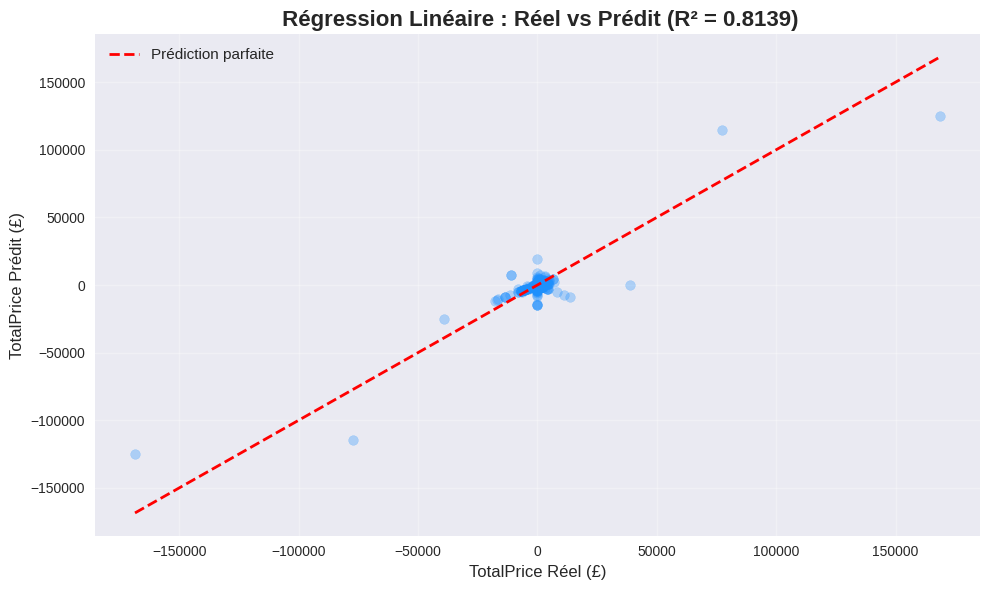


 Si les points sont proches de la ligne rouge, le modèle prédit bien !


In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y, y_pred, alpha=0.3, color='dodgerblue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Prédiction parfaite')
plt.xlabel('TotalPrice Réel (£)', fontsize=12)
plt.ylabel('TotalPrice Prédit (£)', fontsize=12)
plt.title(f' Régression Linéaire : Réel vs Prédit (R² = {r2:.4f})', fontsize=16, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n Si les points sont proches de la ligne rouge, le modèle prédit bien !")

 6.7 - Résidus (erreurs de prédiction)

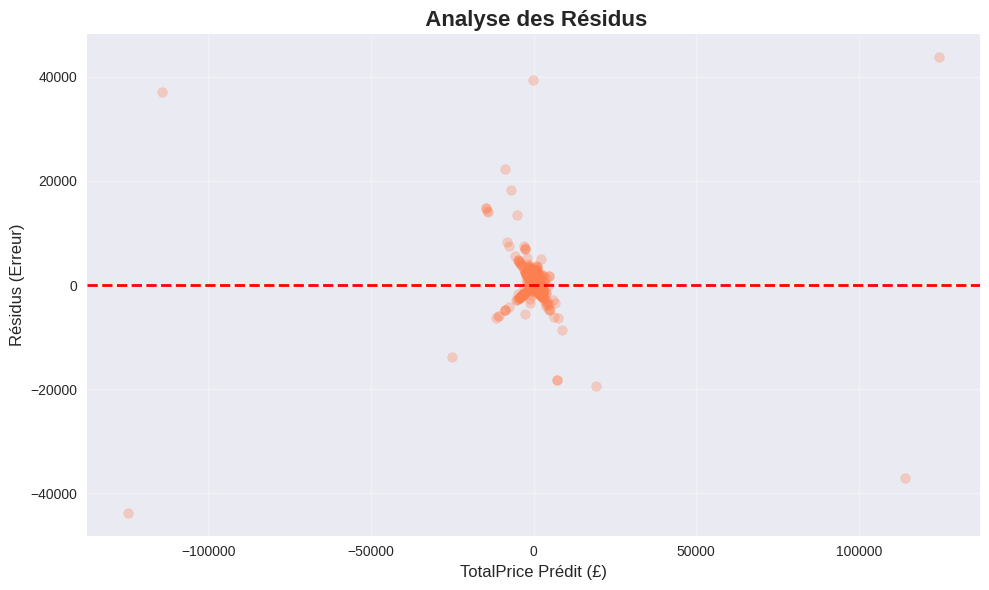


 Les résidus doivent être dispersés aléatoirement autour de 0.
   Si tu vois un pattern, le modèle pourrait être amélioré.


In [ ]:
# Calculer les résidus
residus = y - y_pred

plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residus, alpha=0.3, color='coral')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('TotalPrice Prédit (£)', fontsize=12)
plt.ylabel('Résidus (Erreur)', fontsize=12)
plt.title(' Analyse des Résidus', fontsize=16, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n Les résidus doivent être dispersés aléatoirement autour de 0.")
print("   Si tu vois un pattern, le modèle pourrait être amélioré.")

# 7-SEGMENTATION CLIENT (K-MEANS CLUSTERING)

 7.1 - CONSTRUCTION DES INDICATEURS CLIENT

In [ ]:
print("=" * 70)
print(" CONSTRUCTION DES INDICATEURS CLIENT")
print("=" * 70)

# Agréger les données au niveau client (CustomerID)
indicateurs_clients = df.groupby('CustomerID').agg({
    'TotalPrice': 'sum',        # Montant total dépensé
    'InvoiceNo': 'nunique',     # Nombre total d'achats (commandes uniques)
    'Quantity': 'sum',          # Quantité totale achetée
    'InvoiceDate': 'max'        # Date de la dernière commande
}).reset_index()

# Renommer les colonnes pour plus de clarté
indicateurs_clients.columns = ['CustomerID', 'MontantTotal', 'NbAchats', 'QuantiteTotale', 'DerniereCommande']

# Calculer la récence (jours depuis la dernière commande)
date_reference = df['InvoiceDate'].max()  # Date la plus récente dans les données
indicateurs_clients['Recence'] = (date_reference - indicateurs_clients['DerniereCommande']).dt.days

# Supprimer la colonne DerniereCommande (on n'en a plus besoin)
indicateurs_clients = indicateurs_clients.drop('DerniereCommande', axis=1)

print(f"\n Indicateurs créés pour {len(indicateurs_clients)} clients")
print("\n Aperçu des indicateurs :")
print(indicateurs_clients.head(10))

# Statistiques descriptives
print("\n Statistiques descriptives des indicateurs :")
print(indicateurs_clients[['MontantTotal', 'NbAchats', 'QuantiteTotale', 'Recence']].describe())

 CONSTRUCTION DES INDICATEURS CLIENT

 Indicateurs créés pour 4372 clients

 Aperçu des indicateurs :
   CustomerID  MontantTotal  NbAchats  QuantiteTotale  Recence
0     12346.0          0.00         2               0      325
1     12347.0       4310.00         7            2458        1
2     12348.0       1797.24         4            2341       74
3     12349.0       1757.55         1             631       18
4     12350.0        334.40         1             197      309
5     12352.0       1545.41        11             470       35
6     12353.0         89.00         1              20      203
7     12354.0       1079.40         1             530      231
8     12355.0        459.40         1             240      213
9     12356.0       2811.43         3            1591       22

 Statistiques descriptives des indicateurs :
        MontantTotal     NbAchats  QuantiteTotale      Recence
count    4372.000000  4372.000000     4372.000000  4372.000000
mean     1898.459701     5.075480

 Visualisation des distributions des indicateurs

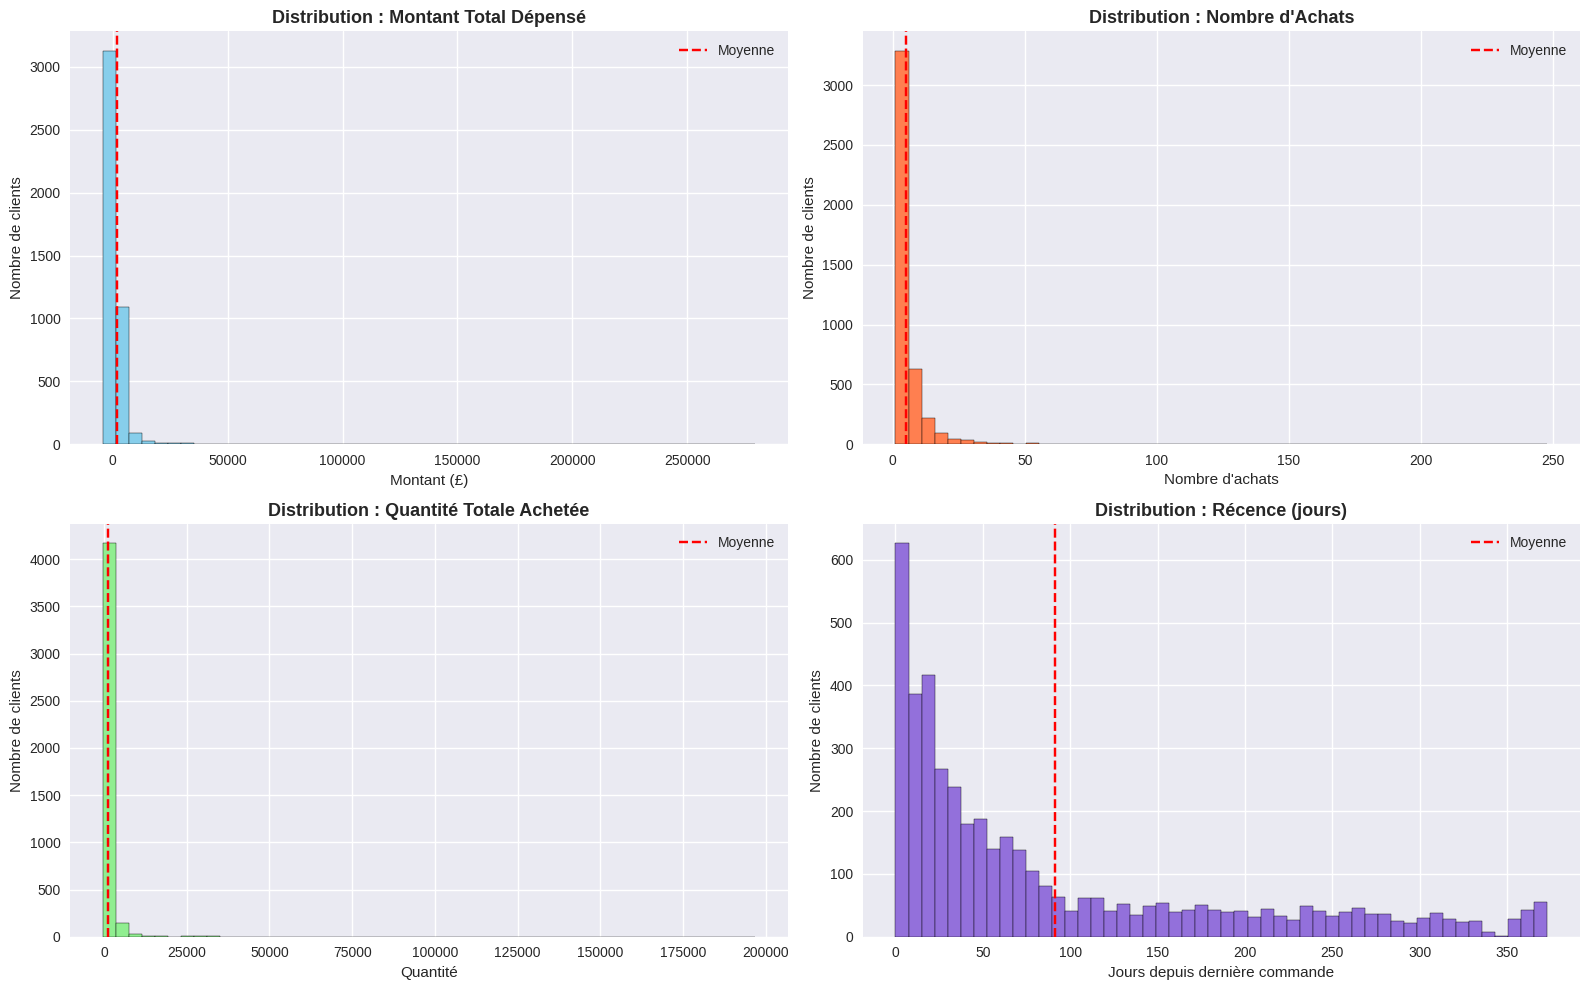


 Ces graphiques montrent la distribution de chaque indicateur.
   On voit souvent des distributions asymétriques (queue longue à droite).


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Montant Total
axes[0, 0].hist(indicateurs_clients['MontantTotal'], bins=50, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Distribution : Montant Total Dépensé', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Montant (£)')
axes[0, 0].set_ylabel('Nombre de clients')
axes[0, 0].axvline(indicateurs_clients['MontantTotal'].mean(), color='red', linestyle='--', label='Moyenne')
axes[0, 0].legend()

# Nombre d'achats
axes[0, 1].hist(indicateurs_clients['NbAchats'], bins=50, color='coral', edgecolor='black')
axes[0, 1].set_title('Distribution : Nombre d\'Achats', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Nombre d\'achats')
axes[0, 1].set_ylabel('Nombre de clients')
axes[0, 1].axvline(indicateurs_clients['NbAchats'].mean(), color='red', linestyle='--', label='Moyenne')
axes[0, 1].legend()

# Quantité totale
axes[1, 0].hist(indicateurs_clients['QuantiteTotale'], bins=50, color='lightgreen', edgecolor='black')
axes[1, 0].set_title('Distribution : Quantité Totale Achetée', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Quantité')
axes[1, 0].set_ylabel('Nombre de clients')
axes[1, 0].axvline(indicateurs_clients['QuantiteTotale'].mean(), color='red', linestyle='--', label='Moyenne')
axes[1, 0].legend()

# Récence
axes[1, 1].hist(indicateurs_clients['Recence'], bins=50, color='mediumpurple', edgecolor='black')
axes[1, 1].set_title('Distribution : Récence (jours)', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Jours depuis dernière commande')
axes[1, 1].set_ylabel('Nombre de clients')
axes[1, 1].axvline(indicateurs_clients['Recence'].mean(), color='red', linestyle='--', label='Moyenne')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print("\n Ces graphiques montrent la distribution de chaque indicateur.")
print("   On voit souvent des distributions asymétriques (queue longue à droite).")

 7.2 - SEGMENTATION PAR K-MEANS


 PRÉPARATION DES DONNÉES POUR LE CLUSTERING

 Aperçu des données standardisées pour le clustering :
    Recence  NbAchats  MontantTotal  QuantiteTotale
0  2.322023 -0.329362     -0.594903       -0.598271
1 -0.893733  0.206102      1.110232        1.053641
2 -0.169196 -0.115176      0.116126        0.975010
3 -0.725005 -0.436455      0.100424       -0.174204
4  2.163220 -0.436455     -0.462606       -0.465877

 MÉTHODE DU COUDE : TROUVER LE NOMBRE OPTIMAL DE CLUSTERS
K = 2 → Inertie = 10258.93
K = 3 → Inertie = 6651.41
K = 4 → Inertie = 4724.64
K = 5 → Inertie = 3590.71
K = 6 → Inertie = 2917.04


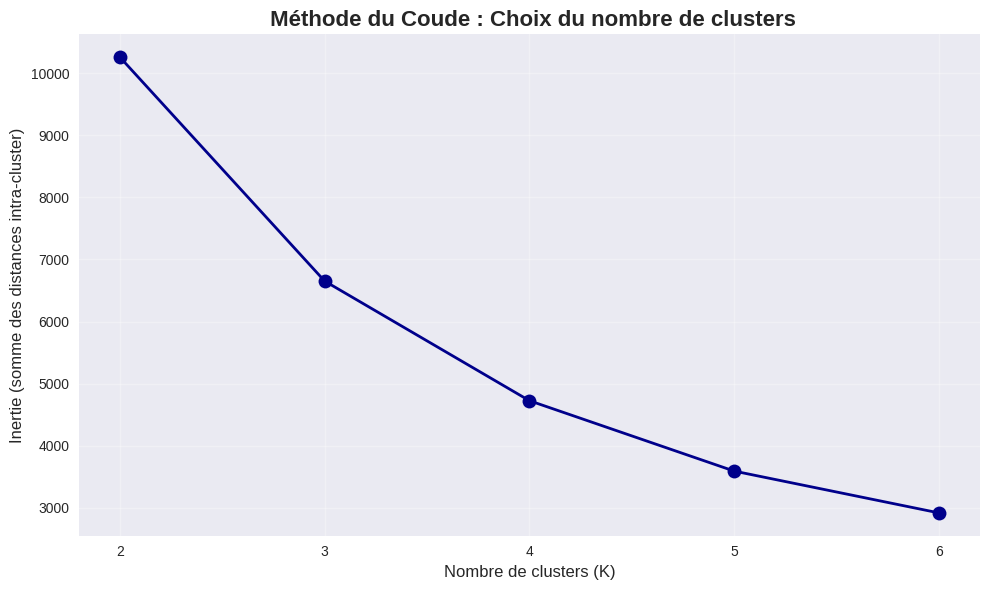


 Le 'coude' est l'endroit où la courbe se stabilise.
   → Choisis K où l'ajout d'un cluster n'améliore plus beaucoup l'inertie.


In [ ]:
from sklearn.cluster import KMeans # Importation déjà ajoutée
from sklearn.preprocessing import StandardScaler # Importation ajoutée
import matplotlib.pyplot as plt # Assurer que plt est importé pour le plot
import numpy as np # Assurer que numpy est importé

print("\n" + "=" * 70)
print(" PRÉPARATION DES DONNÉES POUR LE CLUSTERING")
print("=" * 70)

# 1. Sélection des caractéristiques pour le clustering
features = ['Recence', 'NbAchats', 'MontantTotal', 'QuantiteTotale']
df_clustering = indicateurs_clients[features].copy()

# Gérer les valeurs aberrantes (optionnel mais recommandé pour K-Means)
# Ici, nous allons simplement les limiter pour éviter des distorsions extrêmes
for col in ['MontantTotal', 'QuantiteTotale']:
    q99 = df_clustering[col].quantile(0.99)
    df_clustering[col] = np.where(df_clustering[col] > q99, q99, df_clustering[col])

# 2. Standardisation des données
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_clustering)
df_clustering = pd.DataFrame(df_scaled, columns=features, index=df_clustering.index)

print("\n Aperçu des données standardisées pour le clustering :")
print(df_clustering.head())

print("\n" + "=" * 70)
print(" MÉTHODE DU COUDE : TROUVER LE NOMBRE OPTIMAL DE CLUSTERS")
print("=" * 70)

# Tester de 2 à 6 clusters
inertie_values = []
K_range = range(2, 7)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_clustering[features])
    inertie_values.append(kmeans.inertia_)
    print(f"K = {k} → Inertie = {kmeans.inertia_:.2f}")

# Visualiser la courbe du coude
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertie_values, marker='o', linewidth=2, markersize=10, color='darkblue')
plt.xlabel('Nombre de clusters (K)', fontsize=12)
plt.ylabel('Inertie (somme des distances intra-cluster)', fontsize=12)
plt.title(' Méthode du Coude : Choix du nombre de clusters', fontsize=16, fontweight='bold')
plt.xticks(K_range)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n Le 'coude' est l'endroit où la courbe se stabilise.")
print("   → Choisis K où l'ajout d'un cluster n'améliore plus beaucoup l'inertie.")

In [ ]:
# CHOISIS LE NOMBRE DE CLUSTERS ICI (4)
K_OPTIMAL = 4  #  Adapte selon ton graphique !

print("\n" + "=" * 70)
print(f" APPLICATION DU K-MEANS AVEC K = {K_OPTIMAL}")
print("=" * 70)

# Créer et entraîner le modèle final
kmeans_final = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
indicateurs_clients['Cluster'] = kmeans_final.fit_predict(df_clustering[features])

print(f" Segmentation réalisée avec {K_OPTIMAL} clusters")

# Répartition des clients par cluster
print("\n RÉPARTITION DES CLIENTS PAR CLUSTER :")
print("-" * 70)
repartition = indicateurs_clients['Cluster'].value_counts().sort_index()
for cluster, nb_clients in repartition.items():
    pourcentage = (nb_clients / len(indicateurs_clients)) * 100
    print(f"Cluster {cluster} : {nb_clients:5} clients ({pourcentage:5.2f}%)")


 APPLICATION DU K-MEANS AVEC K = 4
 Segmentation réalisée avec 4 clusters

 RÉPARTITION DES CLIENTS PAR CLUSTER :
----------------------------------------------------------------------
Cluster 0 :  2786 clients (63.72%)
Cluster 1 :   446 clients (10.20%)
Cluster 2 :  1061 clients (24.27%)
Cluster 3 :    79 clients ( 1.81%)


 7.3 - PROFILING DES SEGMENTS (Analyse descriptive)

In [ ]:
print("\n" + "=" * 70)
print(" PROFIL DES CLUSTERS : STATISTIQUES DESCRIPTIVES")
print("=" * 70)

# Calculer les moyennes par cluster
profil_clusters = indicateurs_clients.groupby('Cluster')[['MontantTotal', 'NbAchats', 'QuantiteTotale', 'Recence']].mean()

print("\n🔹 MOYENNES PAR CLUSTER :")
print(profil_clusters.round(2))

# Médiane par cluster
print("\n🔹 MÉDIANES PAR CLUSTER :")
profil_clusters_median = indicateurs_clients.groupby('Cluster')[['MontantTotal', 'NbAchats', 'QuantiteTotale', 'Recence']].median()
print(profil_clusters_median.round(2))

# Créer un tableau récapitulatif plus lisible
print("\n" + "=" * 70)
print(" TABLEAU RÉCAPITULATIF DES PROFILS")
print("=" * 70)

for cluster in range(K_OPTIMAL):
    print(f"\n🔹 CLUSTER {cluster} :")
    print(f"   Montant total moyen    : £{profil_clusters.loc[cluster, 'MontantTotal']:,.2f}")
    print(f"   Nombre d'achats moyen  : {profil_clusters.loc[cluster, 'NbAchats']:.1f}")
    print(f"   Quantité totale moyenne: {profil_clusters.loc[cluster, 'QuantiteTotale']:.1f}")
    print(f"   Récence moyenne        : {profil_clusters.loc[cluster, 'Recence']:.0f} jours")


 PROFIL DES CLUSTERS : STATISTIQUES DESCRIPTIVES

🔹 MOYENNES PAR CLUSTER :
         MontantTotal  NbAchats  QuantiteTotale  Recence
Cluster                                                 
0              955.50      3.72          568.28    44.10
1             5099.40     14.09         3152.29    22.96
2              392.31      1.77          218.49   249.02
3            37309.64     46.43        21340.75     9.34

🔹 MÉDIANES PAR CLUSTER :
         MontantTotal  NbAchats  QuantiteTotale  Recence
Cluster                                                 
0              706.44       3.0           407.5     33.5
1             4490.50      12.5          2716.0     11.0
2              290.36       1.0           139.0    245.0
3            19786.44      34.0         10899.0      3.0

 TABLEAU RÉCAPITULATIF DES PROFILS

🔹 CLUSTER 0 :
   Montant total moyen    : £955.50
   Nombre d'achats moyen  : 3.7
   Quantité totale moyenne: 568.3
   Récence moyenne        : 44 jours

🔹 CLUSTER 1 :
   Montan

 VISUALISATION 1 : Boxplot par cluster

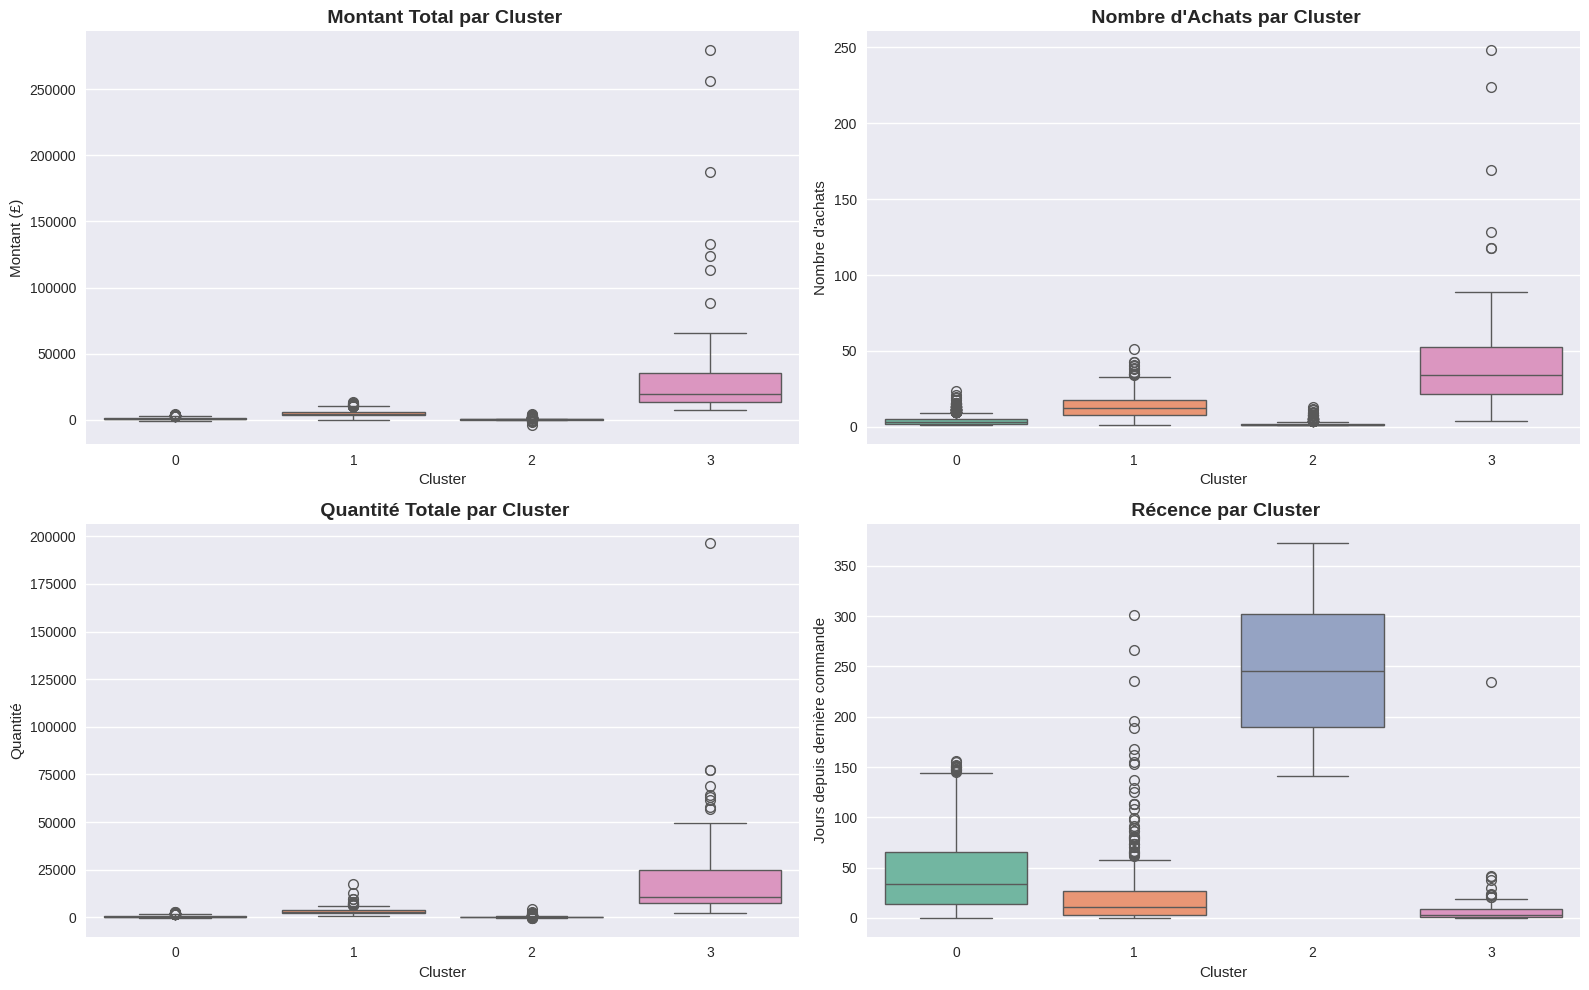

In [ ]:
# Créer des boxplots pour chaque indicateur
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Montant Total
sns.boxplot(data=indicateurs_clients, x='Cluster', y='MontantTotal', palette='Set2', ax=axes[0, 0])
axes[0, 0].set_title(' Montant Total par Cluster', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Montant (£)')

# Nombre d'achats
sns.boxplot(data=indicateurs_clients, x='Cluster', y='NbAchats', palette='Set2', ax=axes[0, 1])
axes[0, 1].set_title(' Nombre d\'Achats par Cluster', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Nombre d\'achats')

# Quantité totale
sns.boxplot(data=indicateurs_clients, x='Cluster', y='QuantiteTotale', palette='Set2', ax=axes[1, 0])
axes[1, 0].set_title(' Quantité Totale par Cluster', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Quantité')

# Récence
sns.boxplot(data=indicateurs_clients, x='Cluster', y='Recence', palette='Set2', ax=axes[1, 1])
axes[1, 1].set_title(' Récence par Cluster', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Jours depuis dernière commande')

plt.tight_layout()
plt.show()

VISUALISATION 2 : Scatter plot 2D avec couleurs de cluster

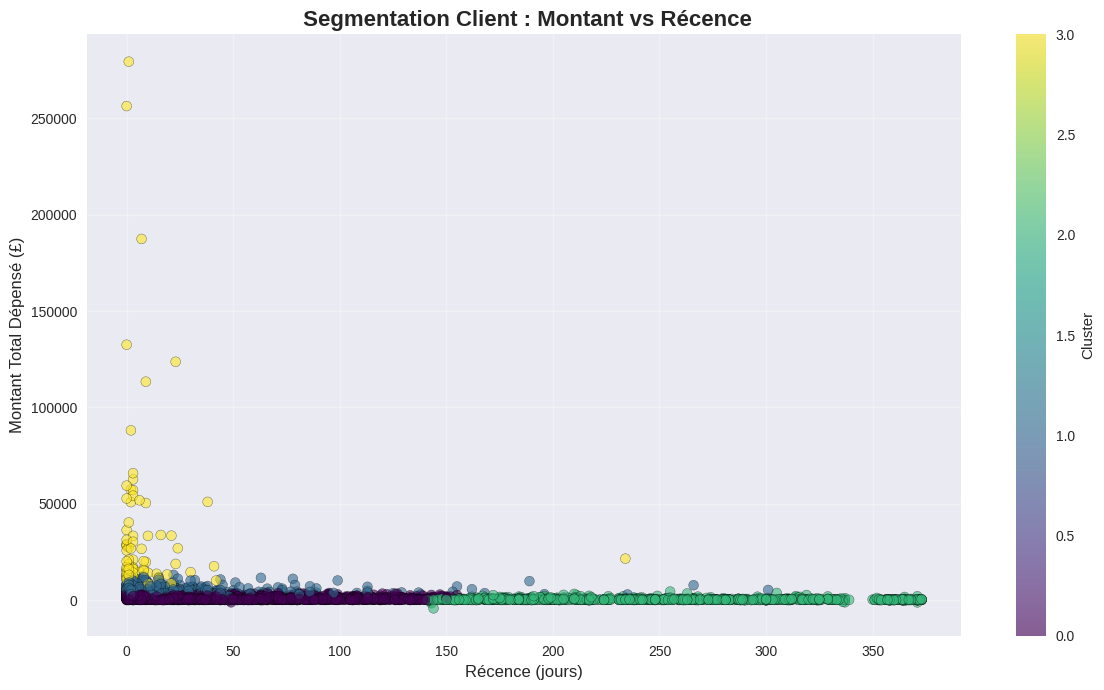


 Ce graphique montre comment les clusters se répartissent selon la récence et le montant.


In [ ]:
# Scatter plot : Montant Total vs Récence (deux variables importantes)
plt.figure(figsize=(12, 7))
scatter = plt.scatter(
    indicateurs_clients['Recence'],
    indicateurs_clients['MontantTotal'],
    c=indicateurs_clients['Cluster'],
    cmap='viridis',
    s=50,
    alpha=0.6,
    edgecolors='black'
)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('Récence (jours)', fontsize=12)
plt.ylabel('Montant Total Dépensé (£)', fontsize=12)
plt.title(' Segmentation Client : Montant vs Récence', fontsize=16, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n Ce graphique montre comment les clusters se répartissent selon la récence et le montant.")

VISUALISATION 3 : Heatmap des profils (comparaison visuelle)

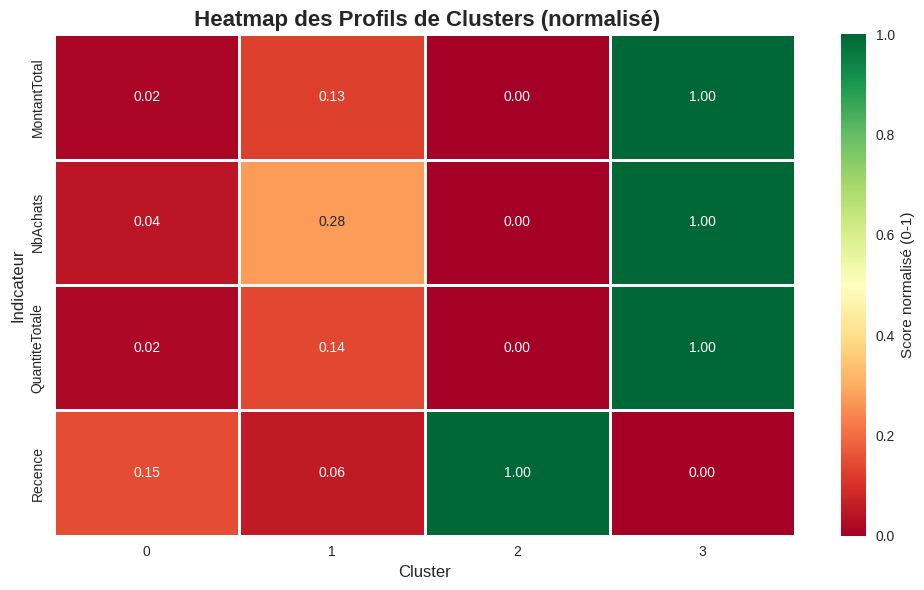


 Vert = valeur élevée, Rouge = valeur faible
   Cette heatmap permet de comparer facilement les clusters.


In [ ]:
# Normaliser les moyennes pour mieux comparer
profil_normalise = profil_clusters.copy()
for col in profil_normalise.columns:
    profil_normalise[col] = (profil_normalise[col] - profil_normalise[col].min()) / (profil_normalise[col].max() - profil_normalise[col].min())

plt.figure(figsize=(10, 6))
sns.heatmap(profil_normalise.T, annot=True, cmap='RdYlGn', fmt='.2f', linewidths=2, cbar_kws={'label': 'Score normalisé (0-1)'})
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Indicateur', fontsize=12)
plt.title(' Heatmap des Profils de Clusters (normalisé)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n Vert = valeur élevée, Rouge = valeur faible")
print("   Cette heatmap permet de comparer facilement les clusters.")

7.4 - INTERPRÉTATION MARKETING

In [ ]:
print("\n" + "=" * 90)
print("💼 INTERPRÉTATION MARKETING DES CLUSTERS")
print("=" * 90)

# Fonction pour nommer les clusters
def interpreter_cluster(row):
    """Donne un nom marketing à chaque cluster"""
    if row['MontantTotal'] > profil_clusters['MontantTotal'].mean() and row['Recence'] < profil_clusters['Recence'].mean():
        return "VIP / Champions"
    elif row['MontantTotal'] > profil_clusters['MontantTotal'].mean() and row['Recence'] > profil_clusters['Recence'].mean():
        return "VIP en sommeil"
    elif row['MontantTotal'] < profil_clusters['MontantTotal'].mean() and row['Recence'] < profil_clusters['Recence'].mean():
        return "Clients réguliers"
    else:
        return "Clients dormants / à réactiver"

# Exemple d'interprétation manuelle (ADAPTE SELON TES RÉSULTATS !)
print("\n🎯 TYPOLOGIE DES CLUSTERS (exemple à adapter) :\n")

for cluster in range(K_OPTIMAL):
    profil = profil_clusters.loc[cluster]
    nb_clients = repartition[cluster]

    print(f"📌 CLUSTER {cluster} — {nb_clients} clients ({nb_clients/len(indicateurs_clients)*100:.1f}%)")
    print(f"   Montant moyen  : £{profil['MontantTotal']:,.0f}")
    print(f"   Achats moyens  : {profil['NbAchats']:.1f}")
    print(f"   Récence moyenne: {profil['Recence']:.0f} jours")

    # Interprétation basée sur les valeurs
    if profil['MontantTotal'] > profil_clusters['MontantTotal'].mean() and profil['Recence'] < profil_clusters['Recence'].mean():
        print(f"    Type : CLIENTS VIP / CHAMPIONS")
        print(f"   → Forte valeur, actifs récemment")
        print(f"   → Actions : Programme fidélité premium, accès anticipé nouveautés")

    elif profil['MontantTotal'] > profil_clusters['MontantTotal'].mean() and profil['Recence'] > profil_clusters['Recence'].mean():
        print(f"     Type : VIP EN SOMMEIL")
        print(f"   → Forte valeur historique mais inactifs")
        print(f"   → Actions : Campagne de réactivation ciblée, offre 'on vous a manqué'")

    elif profil['Recence'] < profil_clusters['Recence'].mean():
        print(f"    Type : CLIENTS RÉGULIERS")
        print(f"   → Actifs mais montant modéré")
        print(f"   → Actions : Upsell, cross-sell, augmenter panier moyen")

    else:
        print(f"    Type : CLIENTS DORMANTS / À RISQUE")
        print(f"   → Faible valeur + inactifs")
        print(f"   → Actions : Réactivation low-cost (email), promotions agressives")

    print()


💼 INTERPRÉTATION MARKETING DES CLUSTERS

🎯 TYPOLOGIE DES CLUSTERS (exemple à adapter) :

📌 CLUSTER 0 — 2786 clients (63.7%)
   Montant moyen  : £956
   Achats moyens  : 3.7
   Récence moyenne: 44 jours
    Type : CLIENTS RÉGULIERS
   → Actifs mais montant modéré
   → Actions : Upsell, cross-sell, augmenter panier moyen

📌 CLUSTER 1 — 446 clients (10.2%)
   Montant moyen  : £5,099
   Achats moyens  : 14.1
   Récence moyenne: 23 jours
    Type : CLIENTS RÉGULIERS
   → Actifs mais montant modéré
   → Actions : Upsell, cross-sell, augmenter panier moyen

📌 CLUSTER 2 — 1061 clients (24.3%)
   Montant moyen  : £392
   Achats moyens  : 1.8
   Récence moyenne: 249 jours
    Type : CLIENTS DORMANTS / À RISQUE
   → Faible valeur + inactifs
   → Actions : Réactivation low-cost (email), promotions agressives

📌 CLUSTER 3 — 79 clients (1.8%)
   Montant moyen  : £37,310
   Achats moyens  : 46.4
   Récence moyenne: 9 jours
    Type : CLIENTS VIP / CHAMPIONS
   → Forte valeur, actifs récemment
   → A